# Setup

In [ ]:
!python -m venv venv

In [2]:
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install pyspssio
!pip install scikit-learn
!pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 55.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 77.1 MB/s  0:00:00m0:00:01
Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 MB 59.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports

Package Imports

In [3]:
import numpy as np
import pandas as pd

from importlib import reload

import matplotlib.pyplot as plt
import seaborn as sns
import pyspssio


Local Imports

In [34]:
import data as d
reload(d)

import visualization as viz
reload(viz)

<module 'visualization' from '/home/lab-member/Alexis/Psych/PsychStats/visualization.py'>

# Loading Data

In [99]:
file_name = "data/enhanced_anxiety_dataset.csv"

In [100]:
data = d.import_data(
    file_path=file_name,
)

# Data Exploration

## Numeric

In [101]:
data.head() 

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [12]:
data.dtypes

Age                                    int64
Gender                                   str
Occupation                               str
Sleep Hours                          float64
Physical Activity (hrs/week)         float64
Caffeine Intake (mg/day)               int64
Alcohol Consumption (drinks/week)      int64
Smoking                                  str
Family History of Anxiety                str
Stress Level (1-10)                    int64
Heart Rate (bpm)                       int64
Breathing Rate (breaths/min)           int64
Sweating Level (1-5)                   int64
Dizziness                                str
Medication                               str
Therapy Sessions (per month)           int64
Recent Major Life Event                  str
Diet Quality (1-10)                    int64
Anxiety Level (1-10)                 float64
dtype: object

In [36]:
data.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10)
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.241727,6.650691,2.942136,286.090000,9.701636,5.856364,90.916000,20.957545,3.080636,2.427818,5.181818,3.929364
std,13.236140,1.227509,1.827825,144.813157,5.689713,2.927202,17.325721,5.160107,1.398877,2.183106,2.895243,2.122533
min,18.000000,2.300000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000
25%,29.000000,5.900000,1.500000,172.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000
50%,40.000000,6.700000,2.800000,273.000000,10.000000,6.000000,92.000000,21.000000,3.000000,2.000000,5.000000,4.000000
75%,51.000000,7.500000,4.200000,382.000000,15.000000,8.000000,106.000000,25.000000,4.000000,4.000000,8.000000,5.000000
max,64.000000,11.300000,10.100000,599.000000,19.000000,10.000000,119.000000,29.000000,5.000000,12.000000,10.000000,10.000000


In [95]:
reload(d)
descriptive = d.get_stats(data, print_metrics=True)

                                 | median                           | count                            | kurtosis                         | min                              | range                            | variance                         | unique                           | std                              | top                              | mean                             | freq                             | skewness                         | max                              | mode                             Age                              | 40.0| NA| -1.1263406319227574| 18| 46| 175.19540387142635| NA| 13.236140066931384| NA| 40.241727272727275| NA| 0.09733621216388642| 64| 0    30
Name: Age, dtype: int64
Gender                           | NA| 11000| NA| NA| NA| NA| <StringArray>
['Female', 'Other', 'Male']
Length: 3, dtype: str| NA| Female| NA| 3730| NA| NA| 0    Female
Name: Gender, dtype: str
Occupation                       | NA| 11000| NA| NA| NA| NA| <StringArray>
[   

In [ ]:
reload(d)
reverse = d.reverse_code(data, "Stress Level (1-10)", inplace=False, add_col=True)

TypeError: 'bool' object is not callable

In [104]:
data

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


## Visualization

Correlation

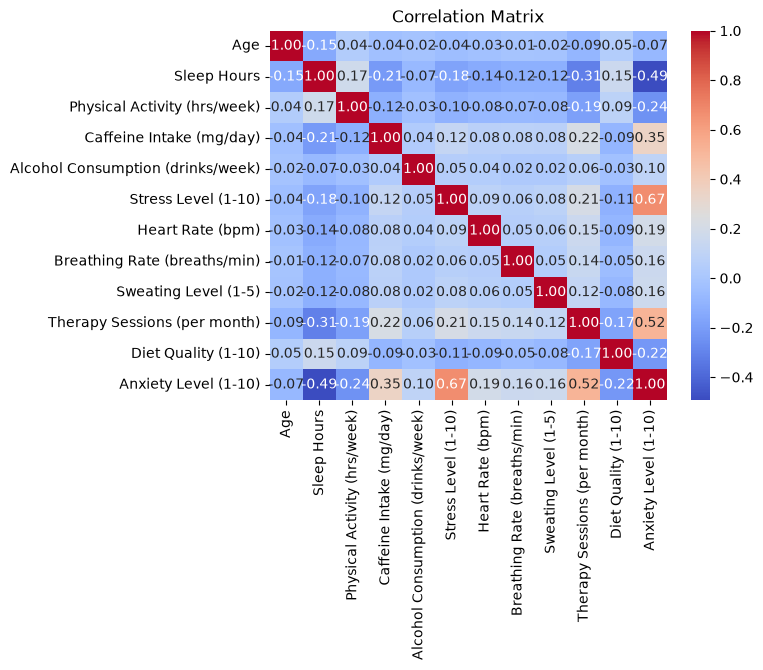

In [26]:
correlation = viz.correlation_matrix(data)

In [27]:
correlation

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10)
Age,1.000000,-0.148349,0.037240,-0.038398,-0.015953,-0.044824,-0.032022,-0.013896,-0.020483,-0.087185,0.048677,-0.074316
Sleep Hours,-0.148349,1.000000,0.174526,-0.208659,-0.068068,-0.177315,-0.138254,-0.119872,-0.118197,-0.309251,0.154110,-0.493836
Physical Activity (hrs/week),0.037240,0.174526,1.000000,-0.115298,-0.032936,-0.103475,-0.076846,-0.071195,-0.075107,-0.188324,0.085587,-0.243187
Caffeine Intake (mg/day),-0.038398,-0.208659,-0.115298,1.000000,0.036401,0.121424,0.076555,0.080000,0.076011,0.216682,-0.089457,0.350651
Alcohol Consumption (drinks/week),-0.015953,-0.068068,-0.032936,0.036401,1.000000,0.051508,0.044271,0.023692,0.023641,0.061931,-0.029601,0.100626
Stress Level (1-10),-0.044824,-0.177315,-0.103475,0.121424,0.051508,1.000000,0.088467,0.062581,0.084936,0.209096,-0.110085,0.667939
Heart Rate (bpm),-0.032022,-0.138254,-0.076846,0.076555,0.044271,0.088467,1.000000,0.053283,0.062168,0.154794,-0.086214,0.188900
Breathing Rate (breaths/min),-0.013896,-0.119872,-0.071195,0.080000,0.023692,0.062581,0.053283,1.000000,0.048349,0.138993,-0.054035,0.157048
Sweating Level (1-5),-0.020483,-0.118197,-0.075107,0.076011,0.023641,0.084936,0.062168,0.048349,1.000000,0.117670,-0.077453,0.160074
Therapy Sessions (per month),-0.087185,-0.309251,-0.188324,0.216682,0.061931,0.209096,0.154794,0.138993,0.117670,1.000000,-0.172908,0.517606


Scatter Plot

In [32]:
xlabel = "Sleep Hours"
ylabel = "Age"


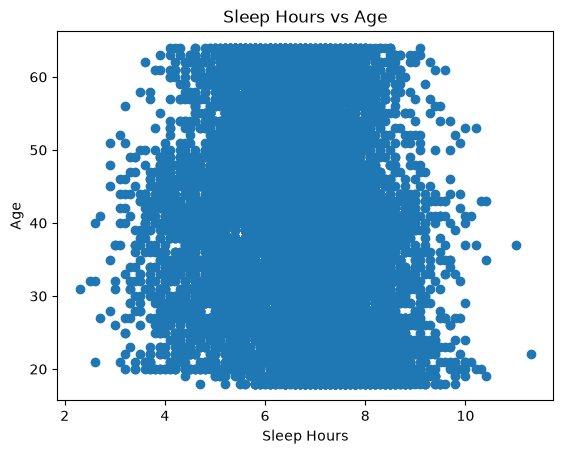

In [33]:
viz.scatter_plot(
    data=data,
    xlabel=xlabel,
    ylabel=ylabel,
)

Distribution